# CIFAR-10 Classification Assignment (PyTorch)

This notebook covers building, training, and comparing Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN) on the CIFAR-10 dataset using PyTorch, along with data augmentation and advanced configurations.

In [1]:
# Install necessary packages into the active Jupyter kernel
%pip install torch torchvision matplotlib pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1 & 2. Load CIFAR-10 & Normalize
Load the CIFAR-10 dataset (50,000 training images, 10,000 evaluation images) and normalize pixel values from 0-255 to 0-1.0.

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ToTensor() automatically converts PIL Images to Tensors and normalizes image channels from 0-255 to 0-1.0
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=0)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=0)

print(f"Training images: {len(trainset)}")
print(f"Evaluation images: {len(testset)}")


Using device: cpu


Training images: 50000
Evaluation images: 10000


## 3. Build a baseline ANN model
Build an ANN on flat vectors using Linear and Dropout layers.

In [3]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(256, 10)
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.drop1(self.relu1(self.fc1(x)))
        x = self.drop2(self.relu2(self.fc2(x)))
        x = self.fc3(x)
        return x

ann_model = ANN().to(device)
print(ann_model)


ANN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


## 4. Build a spatial CNN architecture
Build a spatial CNN architecture using Conv2d, BatchNorm2d, MaxPool2d, Flatten, and Linear classification layers.

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Input shape: (3, 32, 32)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2) # Output: (32, 16, 16)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2) # Output: (64, 8, 8)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

cnn_model = CNN().to(device)
print(cnn_model)


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


## 5. Compile and Train Models
Train both models with Adam optimizer for 10 epochs using CrossEntropyLoss.

In [5]:
# Define a common training function
def train_model(model, train_loader, test_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())
    
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        # Validation phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data in test_loader:
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_acc = correct / total
        val_accuracies.append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f} - Val Accuracy: {val_acc:.4f}")
        
    return val_accuracies

print("Training ANN...")
ann_val_acc = train_model(ann_model, trainloader, testloader, epochs=10)

print("\nTraining CNN...")
cnn_val_acc = train_model(cnn_model, trainloader, testloader, epochs=10)


Training ANN...


Epoch 1/10 - Loss: 1.9567 - Val Accuracy: 0.3266


Epoch 2/10 - Loss: 1.8353 - Val Accuracy: 0.3905


Epoch 3/10 - Loss: 1.7875 - Val Accuracy: 0.4058


Epoch 4/10 - Loss: 1.7519 - Val Accuracy: 0.3960


...

Epoch 6/10 - Loss: 0.5968 - Val Accuracy: 0.7014


Epoch 7/10 - Loss: 0.5397 - Val Accuracy: 0.7147


Epoch 8/10 - Loss: 0.4891 - Val Accuracy: 0.7258


Epoch 9/10 - Loss: 0.4379 - Val Accuracy: 0.7216


Epoch 10/10 - Loss: 0.3946 - Val Accuracy: 0.7202


## 6. Plot validation accuracy
Plot validation accuracy tracking curves for both pipelines on a single chart.

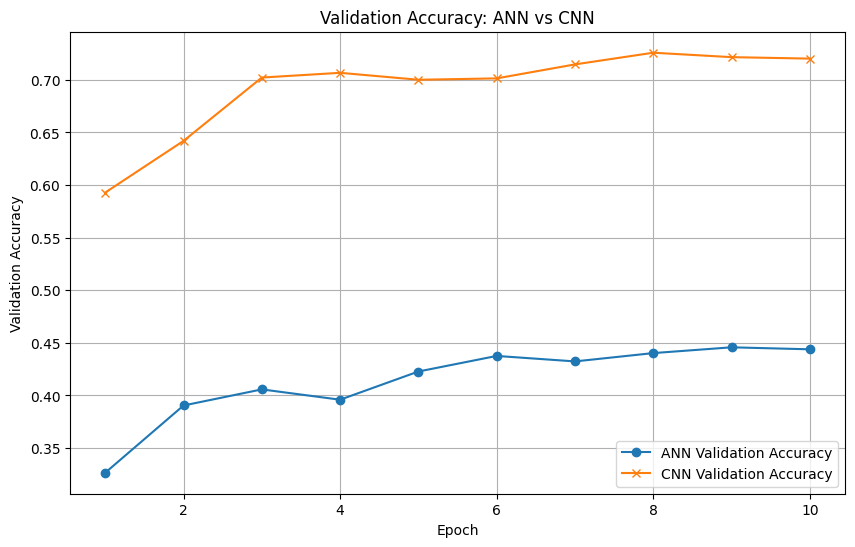

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), ann_val_acc, label='ANN Validation Accuracy', marker='o')
plt.plot(range(1, 11), cnn_val_acc, label='CNN Validation Accuracy', marker='x')
plt.title('Validation Accuracy: ANN vs CNN')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


## 7 & 8. Advanced Data-Augmented Network & Student Tasks
Build an advanced data-augmented network variant and complete student tasks:
- Scale up filter sizes (32->64->128)
- Increase dense layout configurations
- Data augmentation: RandomHorizontalFlip, RandomRotation, and RandomAffine (Zoom/Scale)
- Increase training to 20 epochs
- Integrate EarlyStopping
- Execute the augmented network training run

In [7]:
import copy

# Advanced Data Augmentation pipeline (incorporating flip, rotation, and zoom/scale)
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, scale=(0.9, 1.1)), # Simulating RandomZoom
    transforms.ToTensor()
])

aug_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=aug_transform)
aug_trainloader = torch.utils.data.DataLoader(aug_trainset, batch_size=64, shuffle=True, num_workers=0)

# Advanced CNN Architecture
class AugmentedCNN(nn.Module):
    def __init__(self):
        super(AugmentedCNN, self).__init__()
        # Scale up filter sizes: 32 -> 64 -> 128
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2) # Output: (32, 16, 16)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2) # Output: (64, 8, 8)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2) # Output: (128, 4, 4)
        
        self.flatten = nn.Flatten()
        
        # Increased dense layout configurations
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.drop1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(512, 256)
        self.drop2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(256, 10)
        
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = self.flatten(x)
        x = self.drop1(self.relu(self.fc1(x)))
        x = self.drop2(self.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

aug_cnn_model = AugmentedCNN().to(device)
print(aug_cnn_model)

# Training loop with Early Stopping
def train_model_early_stopping(model, train_loader, test_loader, epochs=20, patience=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())
    
    val_accuracies = []
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for data in test_loader:
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_acc = correct / total
        avg_val_loss = val_loss / len(test_loader)
        val_accuracies.append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {running_loss/len(train_loader):.4f} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.4f}")
        
        # Early Stopping Logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs!")
                break
                
    # Restore best weights
    model.load_state_dict(best_model_wts)
    return val_accuracies

print("\nTraining Augmented CNN for up to 20 Epochs with Early Stopping...")
aug_val_acc = train_model_early_stopping(aug_cnn_model, aug_trainloader, testloader, epochs=20, patience=5)


AugmentedCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (drop1): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (drop2): Dropou

Epoch 1/20 - Train Loss: 1.4937 - Val Loss: 1.2544 - Val Acc: 0.5471


Epoch 2/20 - Train Loss: 1.1623 - Val Loss: 1.3468 - Val Acc: 0.5414


Epoch 3/20 - Train Loss: 1.0286 - Val Loss: 1.0182 - Val Acc: 0.6354


Epoch 4/20 - Train Loss: 0.9357 - Val Loss: 0.8287 - Val Acc: 0.7128


...

Epoch 11/20 - Train Loss: 0.6681 - Val Loss: 0.6313 - Val Acc: 0.7803


Epoch 12/20 - Train Loss: 0.6552 - Val Loss: 0.6219 - Val Acc: 0.7864


Epoch 13/20 - Train Loss: 0.6345 - Val Loss: 0.6651 - Val Acc: 0.7697


Epoch 14/20 - Train Loss: 0.6190 - Val Loss: 0.6009 - Val Acc: 0.7902


Epoch 15/20 - Train Loss: 0.6006 - Val Loss: 0.5971 - Val Acc: 0.7930
Early stopping triggered after 15 epochs!


### Plot Accuracy for Augmented Network

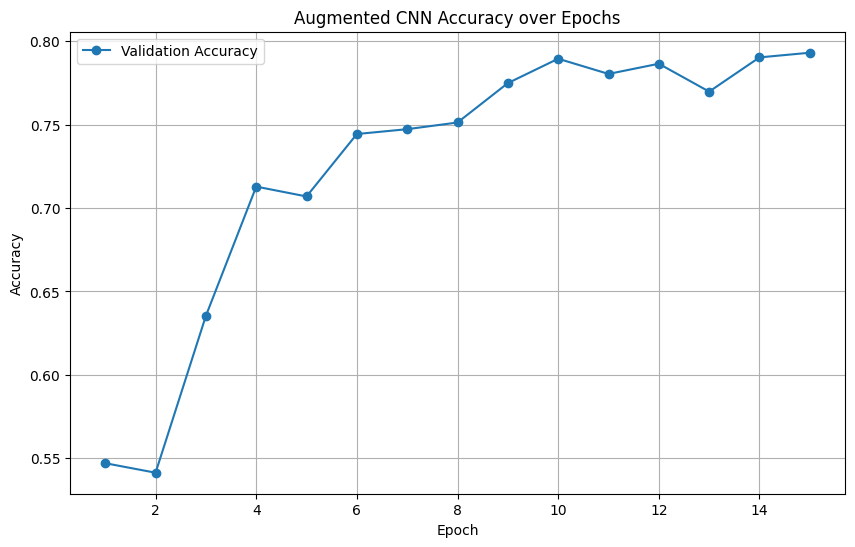

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(aug_val_acc) + 1), aug_val_acc, label='Validation Accuracy', marker='o')
plt.title('Augmented CNN Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


## 9. Final Output Comparison
A dataframe contrasting test accuracy scores between the model variants.

In [9]:
import pandas as pd

comparison_data = {
    'Model Variant': ['Baseline ANN', 'Spatial CNN', 'Augmented CNN (Student Tasks)'],
    'Test Accuracy': [f"{ann_val_acc[-1]*100:.2f}%", f"{cnn_val_acc[-1]*100:.2f}%", f"{aug_val_acc[-1]*100:.2f}%"]
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)


,Model Variant,Test Accuracy
0,Baseline ANN,44.39%
1,Spatial CNN,72.02%
2,Augmented CNN (Student Tasks),79.30%
